### 1. Prerequisitos

#### 1.1 Paquetes
Instalación de paquetes requeridos para la ejecución adecuada del Notebook

In [1]:
!pip install --quiet -r requirements.txt

#### 1.2 Librerías
Importación de librerías requeridas para la ejecución adecuada del Notebook

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,  classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier, RidgeClassifier, Perceptron


#### 1.3 Variables comúnes
Asignación de variables que son utilizadas en diferentes puntos del Notebook

In [2]:
RANDOM_SEED = 42
DATA_PREPR = Path("./data-sources/pre-processed")
MODEL_PATH = Path("./models/classifier/sparse")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

### 2. Datos

#### 2.1 Carga de datos
Carga de los datos a ser utilizados para el entrenamiento de los modelos

In [3]:
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))
df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(f'Registros totales cargados: {len(data)}')

Registros totales cargados: 58963


#### 2.2 Distribución
Distribución de los datos por cada uno de sus grupos (Texto Cientifico y PLS)

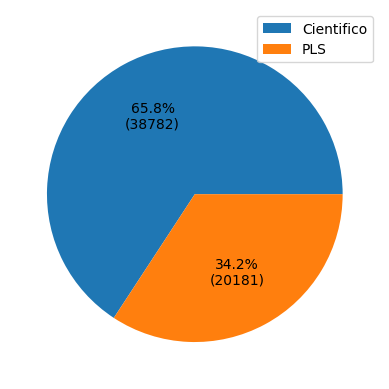

In [4]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

#### 2.3 División de los datos
División de datos en Entrenamiento, Test y Validación, sus porcentajes son 70%, 15% y 15% respectivamente

In [5]:
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5,random_state=RANDOM_SEED,stratify=df_temp['pls'])

x_train,y_train = df_train['text'],df_train['pls']
x_test,y_test = df_test['text'],df_test['pls']
x_val,y_val = df_val['text'],df_val['pls']

print(f'Cantidad de registros dataset entrenamiento: {len(df_train)}, porcentaje {len(df_train)/len(data):.0%}')
print(f'Cantidad de registros dataset validación: {len(df_val)}, porcentaje {len(df_val)/len(data):.0%}')
print(f'Cantidad de registros dataset test: {len(df_test)}, porcentaje {len(df_test)/len(data):.0%}')

Cantidad de registros dataset entrenamiento: 41274, porcentaje 70%
Cantidad de registros dataset validación: 8845, porcentaje 15%
Cantidad de registros dataset test: 8844, porcentaje 15%


### 3. Entrenamiento

#### 3.1 Clases requeridas
Definición de la clase `TextPreprocessor` para realizar la tokenizacion del texto y su limpieza.

In [6]:
class TextPreprocessor():

    def clean_light_text(self, text):
        return text
    
    def tokenize(self, text):
        return text.split()

Calculo de la proporción de balanceo en las clases

In [7]:
c_classes = np.unique(y_train)
c_weight=compute_class_weight(class_weight="balanced", classes=c_classes, y=y_train)
dict_weight = {}
for A, B in zip(c_classes, c_weight):
    dict_weight[int(A)] = float(B)

print(dict_weight)

{0: 0.7601944966294618, 1: 1.4608197069441495}


#### 3.2 Pipeline de entrenamiento

Definición del pipeline para el entrenamiento: Modelos y su parametrización, para el entrenamiento se consideraron los algoritmos:   
- LinearSVC
- LogisticRegression
- RandomForestClassifier
- SGDClassifier
- RidgeClassifier
- PassiveAggressiveClassifier
- Perceptron
- ComplementNB
- MultinomialNB

In [9]:
text_processor = TextPreprocessor()
pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf',LinearSVC())
    ])

tfid_block = {
    'vect__ngram_range': [(1, 2)],
    'vect__max_df': [0.8],
    'vect__min_df': [1],
    'vect__preprocessor': [text_processor.clean_light_text],
    'vect__tokenizer': [text_processor.tokenize],
    'vect__strip_accents': ['ascii'],
    'vect__token_pattern': [None],
    'vect__lowercase': [True]
}

param_grid = [
    {
        'clf': [LinearSVC()],
        'clf__C': [1],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [LogisticRegression(max_iter=500)],
        'clf__solver': ['liblinear', 'saga'],
        'clf__penalty': ['l2'],
        'clf__C': [1],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [RandomForestClassifier(random_state=RANDOM_SEED)],
        'clf__n_estimators': [50],
        'clf__max_depth': [None],
        'clf__min_samples_split': [2],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [SGDClassifier(random_state=RANDOM_SEED)],
        'clf__loss': ['hinge'],
        'clf__alpha': [1e-5],
        'clf__penalty': ['l2'],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [RidgeClassifier(random_state=RANDOM_SEED)],
        'clf__alpha': [0.5, 1.0, 2.0],
        'clf__solver': ['sag'],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [PassiveAggressiveClassifier(random_state=RANDOM_SEED)],
        'clf__C': [0.5, 1.0, 2.0],
        'clf__max_iter': [2000],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [Perceptron(random_state=RANDOM_SEED)],
        'clf__penalty': [None,'l2'],
        'clf__alpha': [1e-3],
        'clf__max_iter': [2000],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [ComplementNB()],
        'clf__alpha': [0.1, 0.5, 1.0],
        **tfid_block
    },
    {
        'clf': [MultinomialNB()],
        'clf__alpha': [0.1, 0.5, 1.0],
        **tfid_block
    }
]

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1_macro',verbose=2,n_jobs=6,return_train_score=True)
grid_search.fit(x_train, y_train)
y_pred = grid_search.predict(x_test)

Fitting 5 folds for each of 19 candidates, totalling 95 fits
[CV] END clf=LinearSVC(), clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, vect__lowercase=True, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x136d020f0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x136d020f0>>; total time=  29.5s
[CV] END clf=LinearSVC(), clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, vect__lowercase=True, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x15c69a0f0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor objec

/Users/htorre/Documents/anaconda/anaconda3/envs/ProyectoMaia/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END clf=SGDClassifier(random_state=42), clf__alpha=1e-05, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, clf__loss=hinge, clf__penalty=l2, vect__lowercase=True, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x10ef9b3e0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x10ef9b3e0>>; total time=  25.2s
[CV] END clf=RidgeClassifier(random_state=42), clf__alpha=0.5, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, clf__solver=sag, vect__lowercase=True, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x1726879b0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.

#### 3.3 Resultados entrenamiento

In [10]:
print("Mejores Hiperparámetros: ", grid_search.best_params_)
print("Mejor puntaje de validación cruzada: {:.5f}".format(grid_search.best_score_))
best_clf = grid_search.best_estimator_.named_steps['clf']
best_clf_name = best_clf.__class__.__name__
print("Algoritmo seleccionado:", best_clf_name)

def obtener_nombre(e):
    try:
        return e.__class__.__name__
    except Exception:
        return str(e)
results = pd.DataFrame(grid_search.cv_results_)

results["estimator_name"] = results["param_clf"].apply(obtener_nombre)
results = results.sort_values("rank_test_score")
results.to_csv(MODEL_PATH/"gridsearch_todos.csv", index=False)

Mejores Hiperparámetros:  {'clf': RidgeClassifier(random_state=42), 'clf__alpha': 0.5, 'clf__class_weight': {0: 0.7601944966294618, 1: 1.4608197069441495}, 'clf__solver': 'sag', 'vect__lowercase': True, 'vect__max_df': 0.8, 'vect__min_df': 1, 'vect__ngram_range': (1, 2), 'vect__preprocessor': <bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x12a880cb0>>, 'vect__strip_accents': 'ascii', 'vect__token_pattern': None, 'vect__tokenizer': <bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x12a880cb0>>}
Mejor puntaje de validación cruzada: 0.99922
Algoritmo seleccionado: RidgeClassifier


In [12]:
def mejores_por_algoritmo_cv(search):

    res = pd.DataFrame(search.cv_results_).copy()
    res["estimator_name"] = res["param_clf"].apply(obtener_nombre)

    res = res.sort_values(
        ["estimator_name", "rank_test_score", "mean_test_score"],
        ascending=[True, True, False]
    )

    best = (res.groupby("estimator_name", as_index=False)
              .first()  
              .sort_values("mean_test_score", ascending=False)
              .reset_index(drop=True))

    cols = ["estimator_name", "mean_test_score", "std_test_score", "rank_test_score", "params"]
    if "mean_train_score" in best.columns:
        cols.insert(2, "mean_train_score")

    return best[cols]

best_per_algo = mejores_por_algoritmo_cv(grid_search)
best_per_algo.to_csv(MODEL_PATH/"gridsearch_mejores_modelos.csv", index=False)

El mejor modelo encontrado por medio de GridSearchCV es un **RidgeClassifier**, esta es la matriz de confusion resultante

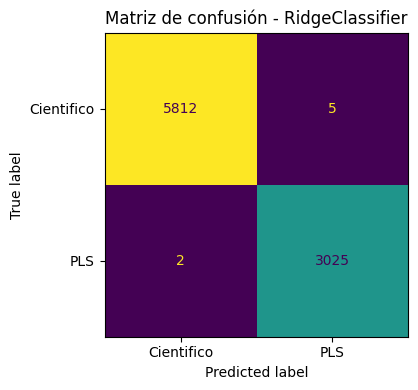

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
conf_mtx = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mtx, display_labels=['Cientifico', 'PLS'])
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión - {best_clf_name}")
plt.tight_layout()
plt.show()

fig.savefig(MODEL_PATH/"cm_train_mejor_modelo.png", dpi=150, bbox_inches="tight")

Métricas del mejor modelo

In [19]:
report_txt=classification_report(y_test, y_pred,digits=4)
print(report_txt)
with open(MODEL_PATH/"cr_train_mejor_modelo.txt", "w", encoding="utf-8") as f:
    f.write(f"Modelo: {best_clf_name}\n")
    f.write(report_txt)

              precision    recall  f1-score   support

           0     0.9997    0.9991    0.9994      5817
           1     0.9983    0.9993    0.9988      3027

    accuracy                         0.9992      8844
   macro avg     0.9990    0.9992    0.9991      8844
weighted avg     0.9992    0.9992    0.9992      8844



Métricas con un dataset de evaluación

In [20]:
y_pred_eval = grid_search.predict(x_val)
print(classification_report(y_val, y_pred_eval,digits=4))

              precision    recall  f1-score   support

           0     0.9993    0.9993    0.9993      5818
           1     0.9987    0.9987    0.9987      3027

    accuracy                         0.9991      8845
   macro avg     0.9990    0.9990    0.9990      8845
weighted avg     0.9991    0.9991    0.9991      8845



Prueba de predicción para un registro

In [21]:
print(x_val.iloc[5])
print(f'Valor Original: {y_val.iloc[5]}')
print(f'Valor Predicho: {grid_search.predict(x_val.iloc[[5]])}')

Background
The risk of cytomegalovirus (CMV) infection in solid organ transplant recipients has resulted in the frequent use of prophylaxis with the aim of preventing the clinical syndrome associated with CMV infection. This is an update of a review first published in 2005 and updated in 2008. 
Objectives
To determine the benefits and harms of antiviral medications to prevent CMV disease and all‐cause mortality in solid organ transplant recipients. 
Search methods
We searched MEDLINE, EMBASE and the Cochrane Central Registry of Controlled Trials (CENTRAL) in The Cochrane Library to February 2004 for the first version of this review. The Cochrane Renal Group's specialised register was searched to February 2007 and to July 2011 for the first and current updates of the review without language restriction. 
Selection criteria
We included randomised controlled trials (RCTs) and quasi‐RCTs comparing antiviral medications with placebo or no treatment, comparing different antiviral medications

Se guarda el modelo en la ruta **models/classifier/sparse**

In [22]:
best_model = grid_search.best_estimator_
dump(best_model, MODEL_PATH/"classifier_sparse.joblib")  

['models/classifier/sparse/classifier_sparse.joblib']

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier

# Asegúrate de tener la misma clase y lógica de antes
text_processor = TextPreprocessor()

pipeline_ridge = Pipeline([
    ('vect', TfidfVectorizer(
        ngram_range=(1, 2),
        max_df=0.8,
        min_df=1,
        preprocessor=text_processor.clean_light_text,
        tokenizer=text_processor.tokenize,
        strip_accents='ascii',
        token_pattern=None,
        lowercase=True
    )),
    ('clf', RidgeClassifier(
        random_state=42,
        alpha=0.5,
        solver='sag',
        class_weight=dict_weight
    ))
])

pipeline_ridge.fit(x_train, y_train)

,steps,"[('vect', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'ascii'
,lowercase,True
,preprocessor,<bound method... 0x118e67170>>
,tokenizer,<bound method... 0x118e67170>>


In [10]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_ridge = CalibratedClassifierCV(
    estimator=pipeline_ridge,
    method='sigmoid',  # Platt scaling
    cv=3               # o 5, si quieres
)

calibrated_ridge.fit(x_train, y_train)

,estimator,Pipeline(step...lver='sag'))])
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'ascii'
,lowercase,True
,preprocessor,<bound method... 0x118e67170>>


In [11]:
from joblib import dump
from pathlib import Path

MODEL_PATH = Path("models/classifier/sparse")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

dump(calibrated_ridge, MODEL_PATH / "classifier_sparse_ridge_calibrated.joblib")

['models/classifier/sparse/classifier_sparse_ridge_calibrated.joblib']

In [ ]:
from joblib import load
# IMPORTANTE: definir o importar TextPreprocessor ANTES de load
# from text_preprocessor import TextPreprocessor
text_processor = TextPreprocessor()

model = load("models/classifier/sparse/classifier_sparse_ridge_calibrated.joblib")

textos = [
    """ Background
Traumatic corneal abrasions are relatively common and there is a lack of consensus about analgesia in their management. It is therefore important to document the clinical efficacy and safety profile of topical ophthalmic non‐steroidal anti‐inflammatory drugs (NSAIDs) in the management of traumatic corneal abrasions. 
Objectives
To identify and evaluate all randomised controlled trials (RCTs) comparing the use of topical NSAIDs with placebo or any alternative analgesic interventions in adults with traumatic corneal abrasions (including corneal abrasions arising from foreign body removal), to reduce pain, and its effects on healing time. 
Search methods
We searched the Cochrane Central Register of Controlled Trials (CENTRAL) (which contains the Cochrane Eyes and Vision Trials Register) (2017, Issue 2), MEDLINE Ovid (1946 to 30 March 2017), Embase Ovid (1947 to 30 March 2017), LILACS (Latin American and Caribbean Health Sciences Literature Database) (1982 to 30 March 2017), OpenGrey (System for Information on Grey Literature in Europe) (www.opengrey.eu/); searched 30 March 2017, ZETOC (1993 to 30 March 2017), the ISRCTN registry (www.isrctn.com/editAdvancedSearch); searched 30 March 2017, ClinicalTrials.gov (www.clinicaltrials.gov); searched 30 March 2017 and the WHO International Clinical Trials Registry Platform (ICTRP) (www.who.int/ictrp/search/en); searched 30 March 2017. We did not use any date or language restrictions in the electronic searches for trials.We checked the reference lists of identified trials to search for further potentially relevant studies. 
Selection criteria
RCTs comparing topical NSAIDs to placebo or any alternative analgesic interventions in adults with traumatic corneal abrasions. 
Data collection and analysis
Two review authors independently performed data extraction and assessed risks of bias in the included studies. We rated the certainty of the evidence using GRADE. 
Main results
We included nine studies that met the inclusion criteria, reporting data on 637 participants.The studies took place in the UK, USA, Israel, Italy, France and Portugal. These studies compared five types of topical NSAIDs (0.1% indomethacin, 0.03% flurbiprofen, 0.5% ketorolac, 1% indomethacin, 0.1% diclofenac) to control (consisting of standard care and in four studies used placebo eye drops). Overall, the studies were at an unclear or high risk of bias (particularly selection and reporting bias). None of the included studies reported the primary outcome measures of this review, namely participant‐reported pain intensity reduction of 30% or more or 50% or more at 24 hours. Four trials, that included data on 481 participants receiving NSAIDs or control (placebo/standard care), reported on the use of ‘rescue’ analgesia at 24 hours as a proxy measure of pain control. Topical NSAIDs were associated with a reduction in the need for oral analgesia compared with control (risk ratio (RR) 0.46, 95% confidence interval (CI) 0.34 to 0.61; low‐certainty evidence). Approximately 4 out of 10 people in the control group used rescue analgesia at 24 hours. No data were available on the use of analgesia at 48 or 72 hours. 
One trial (28 participants) reported on the proportion of abrasions healed after 24 and 48 hours. These outcomes were similar in both arms of the trial. (at 24 hours RR 1.00 (0.81 to 1.23); at 48 hours RR 1.00 (0.88 to 1.14); low‐certainty evidence). In the control group nine out of 10 abrasions were healed within 24 hours and all were healed by 48 hours. Complications of corneal abrasions were reported in 6 studies (609 participants) and were infrequently reported (4 complications, 1 in NSAID groups (recurrent corneal erosion) and 3 in control groups (2 recurrent corneal erosions and 1 corneal abscess), very low‐certainty evidence). Possible drug‐related adverse events (AEs) were reported in two trials (163 participants), with the number of adverse events low (4 AEs, 3 in NSAID group, including discomfort/photophobia on instillation, conjunctival hyperaemia and urticaria, and 1 in the control group, corneal abscess) very low‐certainty evidence. 
Authors' conclusions
The findings of the included studies do not provide strong evidence to support the use of topical NSAIDs in traumatic corneal abrasions. This is important, since NSAIDs are associated with a higher cost compared to oral analgesics. None of the trials addressed our primary outcome measure of participant‐reported pain intensity reduction of 30% or more or 50% or more at 24 hours.""",


    """ Topical non‐steroidal anti‐inflammatory drugs (NSAIDs) for the treatment of pain in traumatic corneal abrasions 
What is the aim of this review?  The aim of this Cochrane Review was to find out if topical (applied directly to the surface of the eye) non‐steroidal anti‐inflammatory drugs (NSAIDs) for traumatic corneal abrasions reduce pain. Cochrane researchers collected and analysed all relevant studies to answer this question. We found nine studies. 
Key messages  It is unclear if using topical NSAIDs is helpful in traumatic corneal abrasions. Topical NSAIDs cost more to use than alternative treatments such as oral pain‐killing tablets. 
What was studied in the review?  A corneal abrasion is a scratch on the cornea of the eye. The cornea is the clear window that is in front of the iris, which is the coloured part of the eye. The cornea is important both for vision and for protecting the eye. When a corneal abrasion occurs, it causes significant pain and discomfort. A traumatic corneal abrasion is a corneal abrasion caused by an injury, such as the eye being poked or something like dirt or sand being trapped under the eyelid and scratching the cornea. 
NSAIDs are one form of pain management for people with corneal abrasions.They may reduce the pain. 
What are the main results of the review?  The Cochrane researchers found nine relevant studies. Three studies each were from the UK and the USA, one from Italy, one from Israel and one from France/Portugal. These studies used five types of topical NSAIDs (0.1% indomethacin, 0.03% flurbiprofen, 0.5% ketorolac, 1% indomethacin, 0.1% diclofenac). The studies compared the topical NSAIDs with antibiotic eye drops, artificial tears, eye patching and dummy (placebo) eye drops. Three of the studies were funded by the manufacturer while the other six studies did not report their funding source. 
The results of the review show that: ∙ It is unclear if people treated with topical NSAIDs experience a clinically meaningful reduction in pain compared with people being treated with placebo or standard care (antibiotic eye drops, artificial tears, eye patching) but they may use less oral pain killers. 
∙ Where drug‐related side effects, and complications of corneal abrasion (e.g. poor healing or infection) were reported (in two trials), the numbers were low. 
How up‐to‐date is this review?  Cochrane researchers searched for studies that had been published up to March 2017.""",   


    """ abscess), very low‐certainty evidence). Possible drug‐related adverse events (AEs) were reported in two trials (163 participants), with the number of adverse events low (4 AEs, 3 in NSAID group, including discomfort/photophobia on instillation, conjunctival hyperaemia and urticaria, and 1 in the control group, corneal abscess) very low‐certainty evidence. 
Authors' conclusions
The findings of the included studies do not provide strong evidence to support the use of topical NSAIDs in traumatic corneal abrasions. This is important, since NSAIDs are associated with a higher cost compared to oral analgesics. None of the trials addressed our primary outcome measure of participant‐reported pain intensity reduction of 30% or more or 50% or more at 24 hours.

PLS:
Plain Title:
Rationale:
Trial Design:
Results:
Key results:
Study characteristics: 
Studies included: 

Students involved: 
 
Review question: 
What is the best way to treat traumatic abrasions? 


Key messages: 
This review was conducted to find out whether topical NSDs can be used to treat trauma. 

 

Key findings: 
None of the included trials reported the primary outcomes of this review. 
   

Study characteristics 
Studies included 9 studies.        
Study participants 638 participants.  



Studies were conducted in the UK and USA.     
Study duration 24 to 48 weeks.    


Key results 
Topical NSD treatment did not improve pain control.     


Conclusion 
This is important, because NSDs are associated to a higher cost than oral analgesic treatments."""
]

y_pred = model.predict(textos)
probs = model.predict_proba(textos)  # shape (n_muestras, n_clases)

print("Clases del modelo:", model.classes_)

Clases del modelo: [0 1]


In [15]:
for t, y, p in zip(textos, y_pred, probs):
    prob_pls = p[1] * 100  # porcentaje
    print("Texto:", t[:70], "...")
    print("Clase predicha:", y)
    print("Probabilidad PLS:", f"{prob_pls:.2f}%")
    print("---")

Texto:  Background
Traumatic corneal abrasions are relatively common and ther ...
Clase predicha: 0
Probabilidad PLS: 0.00%
---
Texto:  Topical non‐steroidal anti‐inflammatory drugs (NSAIDs) for the treatm ...
Clase predicha: 1
Probabilidad PLS: 100.00%
---
Texto:  abscess), very low‐certainty evidence). Possible drug‐related adverse ...
Clase predicha: 1
Probabilidad PLS: 99.99%
---
